# 03 — Classifier Comparison and Final Fraud Detection Model

**Goal:** Use the best embedding from Notebook 02 and compare several classifiers.  

## Workflow
1. Start with the best embedding selected in Notebook 02 (TF-IDF by default)
2. Compare 4 classifiers on the same train/test split
3. Evaluate with fraud-relevant metrics: **F1**, **Recall**, **ROC-AUC**
4. Validate with 5-fold cross-validation
5. Select and save the final model

## 0. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

plt.style.use("ggplot")

FILE_PATH = r"C:/Users/user/Documents/data_science_bootcamp_challenges_project/capstone_project/amit_kedia_dataset.csv"
RANDOM_STATE = 42

# --- EMBEDDING SWITCH ---
# Set to "tfidf" or "finbert"
# If "finbert", make sure X_train_finbert.npy and X_test_finbert.npy exist (saved in notebook 02)
EMBEDDING = "finbert"

print(f"Using embedding: {EMBEDDING}")

Using embedding: finbert


## 1. Load and preprocess the dataset

In [3]:
df = pd.read_csv(FILE_PATH).drop_duplicates().reset_index(drop=True)

def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Fillings"].astype(str).apply(clean_text)
df["target"] = df["Fraud"].map({"no": 0, "yes": 1})

X_text = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train_text)} | Test: {len(X_test_text)}")
print(f"Fraud rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Train: 136 | Test: 34
Fraud rate — Train: 50.00% | Test: 50.00%


## 2. Build features

- **TF-IDF** (default): built here with bigrams for stronger coverage
- **FinBERT**: loaded from saved `.npy` files (produced in Notebook 02)

In [4]:
if EMBEDDING == "tfidf":
    tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
    X_train_vec = tfidf_vectorizer.fit_transform(X_train_text)
    X_test_vec = tfidf_vectorizer.transform(X_test_text)
    print("TF-IDF matrix shapes:")
    print(f"  Train: {X_train_vec.shape}")
    print(f"  Test:  {X_test_vec.shape}")

elif EMBEDDING == "finbert":
    X_train_vec = np.load("X_train_finbert.npy")
    X_test_vec = np.load("X_test_finbert.npy")
    tfidf_vectorizer = None
    print("FinBERT embeddings loaded:")
    print(f"  Train: {X_train_vec.shape}")
    print(f"  Test:  {X_test_vec.shape}")

else:
    raise ValueError(f"Unknown embedding: {EMBEDDING}. Choose 'tfidf' or 'finbert'.")

FinBERT embeddings loaded:
  Train: (136, 768)
  Test:  (34, 768)


## 3. Evaluation helpers

In [5]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Fit, predict, and return metrics + artifacts."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Get probability scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_te)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1_score": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    }
    return model, y_pred, y_prob, metrics

def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-Fraud", "Fraud"],
                yticklabels=["Non-Fraud", "Fraud"])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

## 4. Compare classifiers

All models use `class_weight='balanced'` to handle class imbalance.  
Note: **Naive Bayes only works with TF-IDF** (requires non-negative sparse input).

In [6]:
# Define classifiers
models_to_compare = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE)
}

# Add Naive Bayes only for TF-IDF (sparse non-negative)
if EMBEDDING == "tfidf":
    models_to_compare["Naive Bayes"] = MultinomialNB()

# Run comparison
trained_models = {}
predictions = {}
probabilities = {}
results_list = []

for name, model in models_to_compare.items():
    print(f"Training: {name}...")
    fitted, y_pred, y_prob, metrics = evaluate_model(
        name, model, X_train_vec, X_test_vec, y_train, y_test)
    trained_models[name] = fitted
    predictions[name] = y_pred
    probabilities[name] = y_prob
    results_list.append(metrics)

results_df = pd.DataFrame(results_list).sort_values("f1_score", ascending=False)
print("\n=== Classifier Comparison ===")
display(results_df.round(4))

Training: Logistic Regression...
Training: Linear SVM...
Training: Random Forest...
Training: Gradient Boosting...

=== Classifier Comparison ===


,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.8235,0.7895,0.8824,0.8333,0.7785
0,Logistic Regression,0.6471,0.6923,0.5294,0.6000,0.7820
3,Gradient Boosting,0.6471,0.6923,0.5294,0.6000,0.8028
1,Linear SVM,0.6176,0.6429,0.5294,0.5806,0.7093


## 5. Visualizations

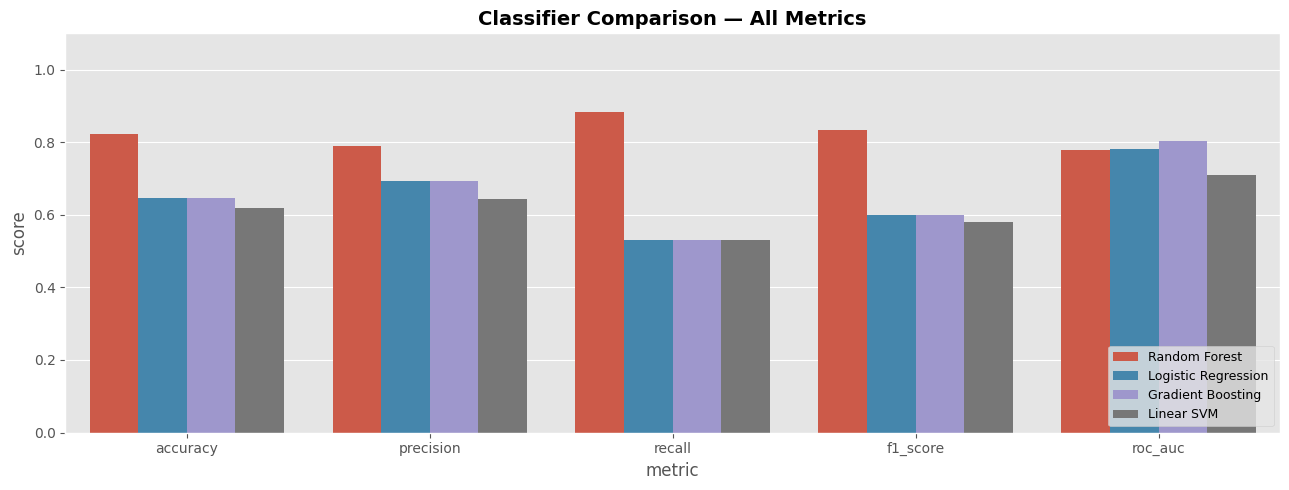

In [7]:
# All metrics bar chart
metrics_cols = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
melt_df = results_df.melt(id_vars="model", value_vars=metrics_cols,
                           var_name="metric", value_name="score")

plt.figure(figsize=(13, 5))
sns.barplot(data=melt_df, x="metric", y="score", hue="model")
plt.title("Classifier Comparison — All Metrics", fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

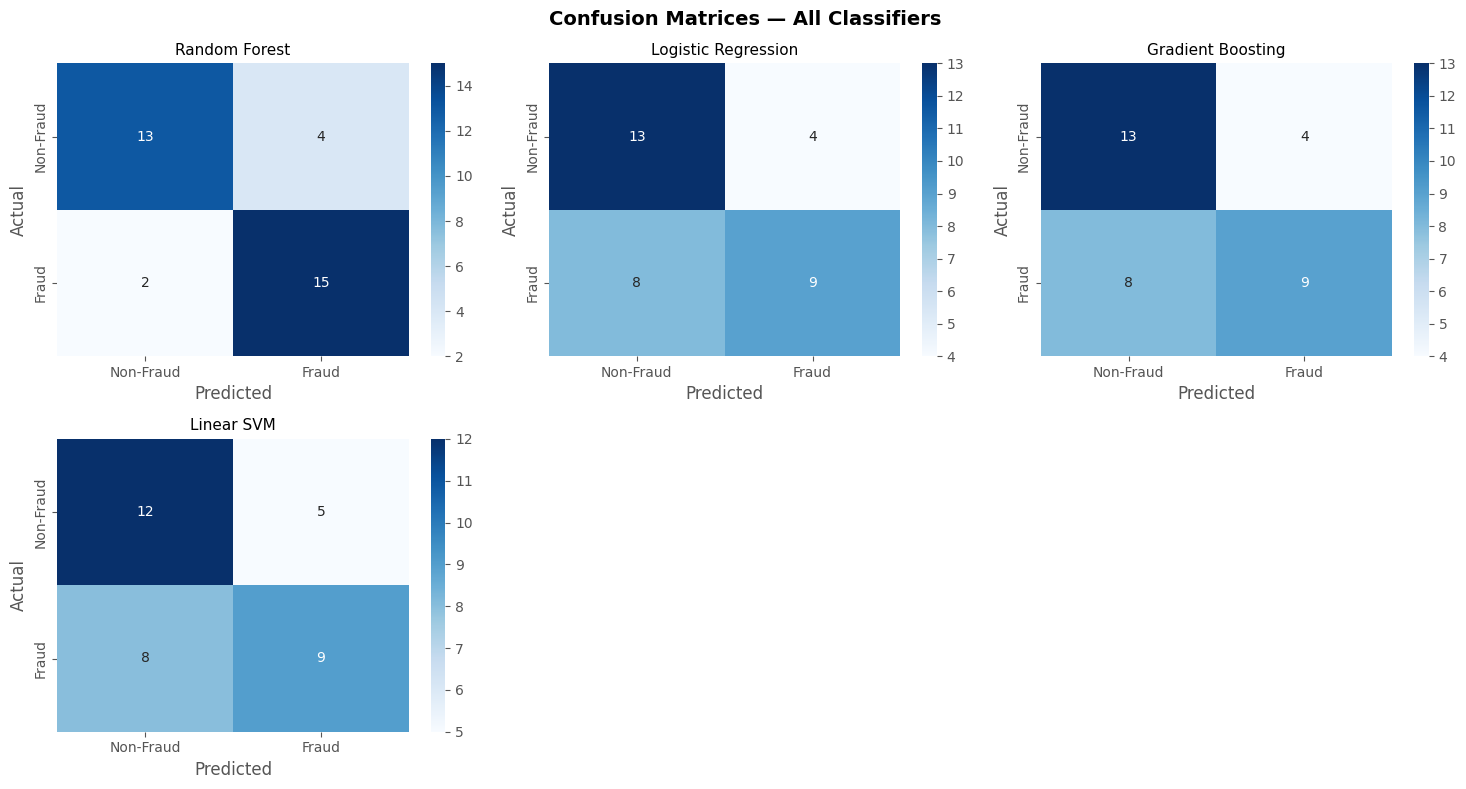

In [8]:
# Confusion matrices — sorted by F1
n = len(results_df)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, model_name in enumerate(results_df["model"]):
    plot_confusion(y_test, predictions[model_name], model_name, axes[i])

# Hide extra axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — All Classifiers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

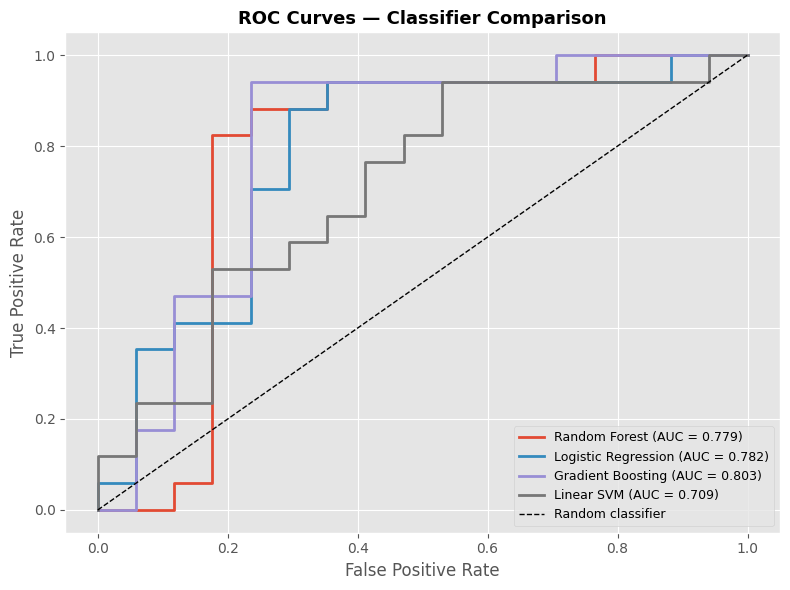

In [9]:
# ROC curves for all classifiers
plt.figure(figsize=(8, 6))

for name in results_df["model"]:
    proba = probabilities[name]
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Cross-validation — robustness check

With a small dataset (~170 rows), a single train/test split can be unreliable.  
**5-fold stratified cross-validation** gives a more stable estimate.

In [11]:
# Rebuild feature matrix on full dataset for cross-validation
if EMBEDDING == "tfidf":
    X_full = tfidf_vectorizer.fit_transform(X_text)
elif EMBEDDING == "finbert":
    X_full = np.load("X_full_finbert.npy")  # saved full embeddings in nb02

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

# Skip Naive Bayes for cross-val simplicity (it doesn't support all embedding types)
for name, model in models_to_compare.items():
    scores = cross_val_score(model, X_full, y, cv=cv, scoring="f1")
    cv_results.append({
        "model": name,
        "cv_f1_mean": scores.mean(),
        "cv_f1_std": scores.std(),
        "cv_f1_scores": scores.round(3).tolist()
    })
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("cv_f1_mean", ascending=False)
display(cv_df[["model", "cv_f1_mean", "cv_f1_std"]].round(4))

Logistic Regression: F1 = 0.6935 ± 0.0333
Linear SVM: F1 = 0.6914 ± 0.0414
Random Forest: F1 = 0.6940 ± 0.0629
Gradient Boosting: F1 = 0.7480 ± 0.0617


,model,cv_f1_mean,cv_f1_std
3,Gradient Boosting,0.7480,0.0617
2,Random Forest,0.6940,0.0629
0,Logistic Regression,0.6935,0.0333
1,Linear SVM,0.6914,0.0414


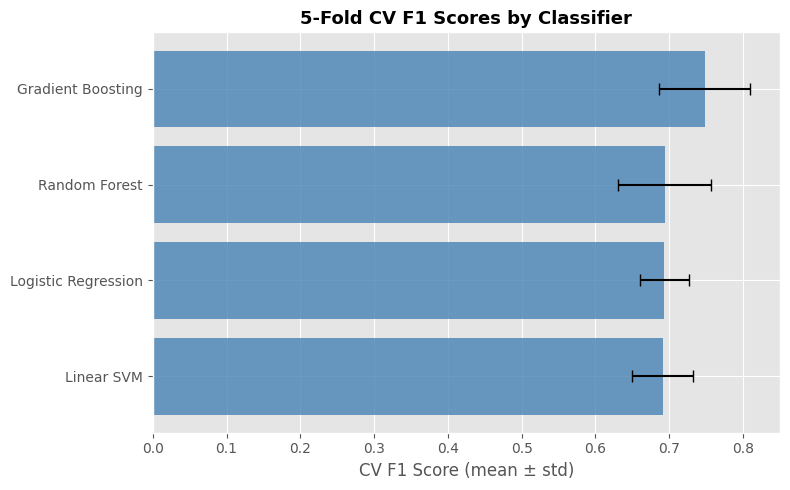

In [12]:
plt.figure(figsize=(8, 5))
plt.barh(
    cv_df["model"],
    cv_df["cv_f1_mean"],
    xerr=cv_df["cv_f1_std"],
    color="steelblue",
    alpha=0.8,
    capsize=4
)
plt.xlabel("CV F1 Score (mean ± std)")
plt.title("5-Fold CV F1 Scores by Classifier", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Select the final model

In fraud detection, we prioritize **recall** and **F1-score** for the fraud class because:
- A **false negative** (missed fraud) is far more costly than a false positive
- We also consider **stability** (CV std) and **interpretability**

Selected model: Random Forest

Final performance on test set:
              precision    recall  f1-score   support

   Non-Fraud       0.87      0.76      0.81        17
       Fraud       0.79      0.88      0.83        17

    accuracy                           0.82        34
   macro avg       0.83      0.82      0.82        34
weighted avg       0.83      0.82      0.82        34



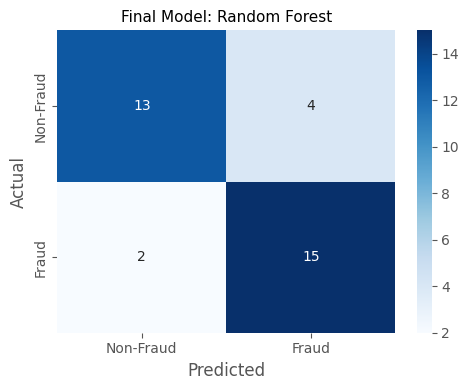

In [13]:
# Select based on F1-score from test set (change to cv_f1_mean for CV-based selection)
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print(f"Selected model: {best_model_name}")
print()
print("Final performance on test set:")
print(classification_report(y_test, predictions[best_model_name],
                             target_names=["Non-Fraud", "Fraud"]))

# Final confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test, predictions[best_model_name],
               f"Final Model: {best_model_name}", ax)
plt.tight_layout()
plt.show()

## 8. Feature importance (if applicable)

In [14]:
if EMBEDDING == "tfidf" and hasattr(best_model, "coef_"):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    coef = best_model.coef_[0]
    top_n = 20

    top_fraud_idx = np.argsort(coef)[-top_n:][::-1]
    top_nonfraud_idx = np.argsort(coef)[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    pd.Series(coef[top_fraud_idx], index=feature_names[top_fraud_idx]).plot(
        kind="barh", ax=axes[0], color="#e74c3c")
    axes[0].set_title("Top Features → Fraud", fontsize=12)
    axes[0].invert_yaxis()

    pd.Series(coef[top_nonfraud_idx], index=feature_names[top_nonfraud_idx]).plot(
        kind="barh", ax=axes[1], color="#2ecc71")
    axes[1].set_title("Top Features → Non-Fraud", fontsize=12)
    axes[1].invert_yaxis()

    plt.suptitle(f"Feature Importance — {best_model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

elif EMBEDDING == "tfidf" and hasattr(best_model, "feature_importances_"):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-20:][::-1]

    plt.figure(figsize=(10, 6))
    pd.Series(importances[top_idx], index=feature_names[top_idx]).sort_values().plot(
        kind="barh", color="steelblue")
    plt.title(f"Top 20 Feature Importances — {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

else:
    print("Feature importance not available for this model/embedding combination.")

Feature importance not available for this model/embedding combination.


## 9. Sample predictions

In [15]:
sample_texts = X_test_text.iloc[:5].tolist()
true_labels = y_test.iloc[:5].tolist()

if EMBEDDING == "tfidf":
    sample_vecs = tfidf_vectorizer.transform(sample_texts)
elif EMBEDDING == "finbert":
    sample_vecs = X_test_vec[:5]

sample_preds = best_model.predict(sample_vecs)
if hasattr(best_model, "predict_proba"):
    sample_proba = best_model.predict_proba(sample_vecs)[:, 1]
else:
    sample_proba = [None] * len(sample_preds)

pd.DataFrame({
    "text_preview": [t[:100] + "..." for t in sample_texts],
    "true_label": ["Fraud" if l == 1 else "Non-Fraud" for l in true_labels],
    "predicted_label": ["Fraud" if p == 1 else "Non-Fraud" for p in sample_preds],
    "fraud_probability": [round(p, 3) if p is not None else "N/A" for p in sample_proba],
    "correct": ["✓" if t == p else "✗" for t, p in zip(true_labels, sample_preds)]
})

,text_preview,true_label,predicted_label,fraud_probability,correct
0,item principal accountant fees services inform...,Non-Fraud,Non-Fraud,0.420,✓
1,item exhibits financial statement schedules re...,Fraud,Fraud,0.600,✓
2,item exhibits financial statement schedules re...,Fraud,Fraud,0.565,✓
3,item principal accounting fees services omitte...,Non-Fraud,Non-Fraud,0.420,✓
4,item principal accountant fees services inform...,Non-Fraud,Non-Fraud,0.485,✓


## 10. Overfitting check

In [16]:
overfit_results = []

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train_vec)
    y_test_pred  = predictions[name]

    overfit_results.append({
        "model"       : name,
        "train_f1"    : f1_score(y_train, y_train_pred, zero_division=0),
        "test_f1"     : f1_score(y_test,  y_test_pred,  zero_division=0),
        "gap"         : f1_score(y_train, y_train_pred, zero_division=0) - 
                        f1_score(y_test,  y_test_pred,  zero_division=0)
    })

overfit_df = pd.DataFrame(overfit_results).sort_values("gap", ascending=False)
display(overfit_df.round(4))

,model,train_f1,test_f1,gap
1,Linear SVM,1.0000,0.5806,0.4194
3,Gradient Boosting,1.0000,0.6000,0.4000
0,Logistic Regression,0.9927,0.6000,0.3927
2,Random Forest,1.0000,0.8333,0.1667


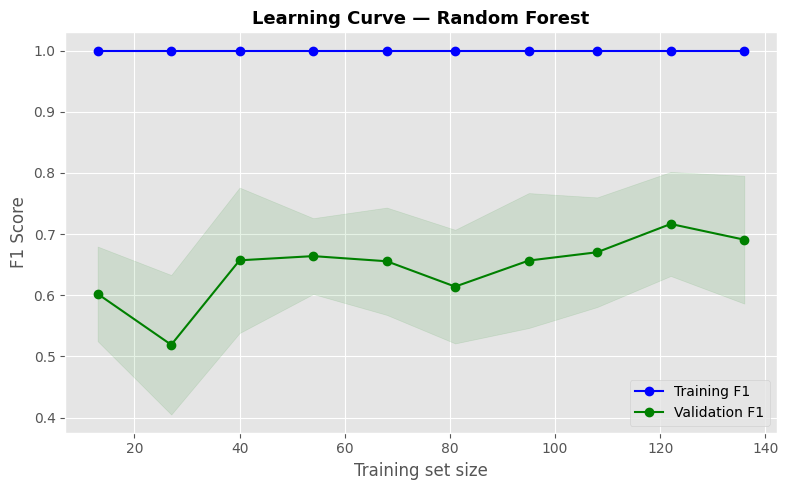

In [17]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5, scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, "o-", color="blue",  label="Training F1")
    plt.plot(train_sizes, val_mean,   "o-", color="green", label="Validation F1")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.1, color="green")
    plt.title(f"Learning Curve — {title}", fontsize=13, fontweight="bold")
    plt.xlabel("Training set size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Run for your best model
plot_learning_curve(best_model, X_full, y, best_model_name)

## 11. Save the final model

In [ ]:
joblib.dump(best_model, "fraud_detection_final_model.pkl")
print("Saved: fraud_detection_final_model.pkl")

if EMBEDDING == "tfidf" and tfidf_vectorizer is not None:
    joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
    print("Saved: tfidf_vectorizer.pkl")

# Save model metadata
import json
metadata = {
    "model_name": best_model_name,
    "embedding": EMBEDDING,
    "test_f1": round(results_df.iloc[0]["f1_score"], 4),
    "test_recall": round(results_df.iloc[0]["recall"], 4),
    "test_roc_auc": round(results_df.iloc[0]["roc_auc"], 4),
    "train_size": len(X_train_text),
    "test_size": len(X_test_text)
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: model_metadata.json")
print()
print(json.dumps(metadata, indent=2))

## 12. Final Conclusions

### Project summary

This project applies NLP-based machine learning to detect fraud in SEC financial filings using the Amit Kedia dataset.

### Pipeline recap

| Step | Description |
|------|-------------|
| **Notebook 01** | EDA: class distribution, text length, vocabulary differences, TF-IDF term importance |
| **Notebook 02** | Embedding comparison: TF-IDF vs FinBERT (fixed Logistic Regression classifier) |
| **Notebook 03** | Classifier comparison on the best embedding + cross-validation + final model selection |

### Why this approach makes sense
- **Text-based fraud detection** is well-suited for SEC filings: language patterns in MD&A sections differ between fraudulent and legitimate companies
- **class_weight='balanced'** corrects for any class imbalance without discarding data
- **Recall** is prioritized over precision: in fraud detection, missing a true fraud case is more costly than a false alarm
- **Cross-validation** validates results beyond a single split, especially important on small datasets

### Deployment
The saved `fraud_detection_final_model.pkl` and `tfidf_vectorizer.pkl` can be integrated into an API or auditing tool that accepts financial filing text and returns a fraud probability score.